In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("/mnt/c/Users/Vikash Rathore/OneDrive/Desktop/Energy Load Predictor/datasets/v1/ercot_combined.csv")

In [46]:
ercot_raw = pd.read_csv(DATA_PATH)

In [47]:
ercot_raw.head()


,TIME,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,ERCOT
0,2002-01-01 01:00:00,8331.469266,1111.096549,1094.045496,995.298392,10336.30490,2165.007571,4793.193560,843.747177,29670.16291
1,2002-01-01 02:00:00,8107.805431,1091.481584,1083.517981,981.195477,10178.05274,2092.374118,4766.918187,835.488188,29136.83370
2,2002-01-01 03:00:00,7890.721717,1080.257616,1085.038740,971.305257,10100.88771,2042.080714,4702.918892,830.694878,28703.90552
3,2002-01-01 04:00:00,7799.817527,1079.726403,1093.381853,971.262963,10081.56511,2011.935791,4669.064391,835.068413,28541.82245
4,2002-01-01 05:00:00,7815.968171,1087.934961,1106.651296,982.535591,10192.21867,2002.487678,4695.011904,848.598209,28731.40648


In [48]:
ercot_raw["timestamp"] = pd.to_datetime(ercot_raw["TIME"])
ercot = ercot_raw.set_index("timestamp").sort_index()

In [49]:
ercot = ercot[["ERCOT", "COAST", "EAST", "FWEST", "NORTH", "NCENT", "SOUTH", "WEST"]]
ercot.rename(columns={"ERCOT": "load"}, inplace=True)

In [50]:
print(f"ERCOT Shape: {ercot.shape}")
print(f"Date Range:  {ercot.index.min()} to {ercot.index.max()}")
print(f"Missing Values:\n{ercot.isnull().sum()}")

ERCOT Shape: (201624, 8)
Date Range:  2002-01-01 01:00:00 to 2025-01-01 00:00:00
Missing Values:
load     1
COAST    1
EAST     1
FWEST    1
NORTH    1
NCENT    1
SOUTH    1
WEST     1
dtype: int64


In [51]:
time_diffs = ercot.index.to_series().diff().value_counts()
print(f"\nStep distribution:\n{time_diffs.head()}")


Step distribution:
timestamp
0 days 01:00:00    201577
0 days 02:00:00        23
0 days 00:00:00        23
Name: count, dtype: int64


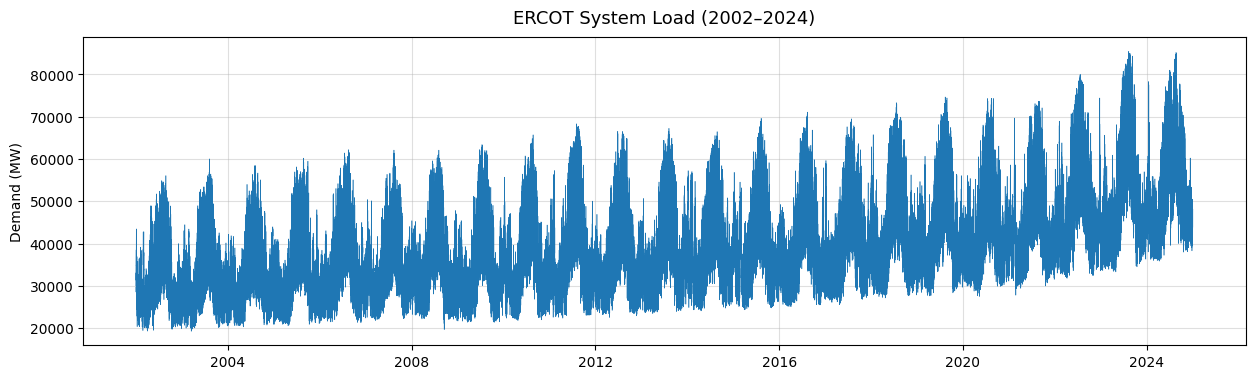

In [52]:
#2002-2024 ERCOT System Load Profile
plt.figure(figsize=(15, 4))
plt.plot(ercot.index, ercot["load"], linewidth=0.4, color="#1f77b4")
plt.title("ERCOT System Load (2002-2024)", fontsize=13, pad=10)
plt.ylabel("Demand (MW)")
plt.grid(True, alpha=0.4)
plt.show()

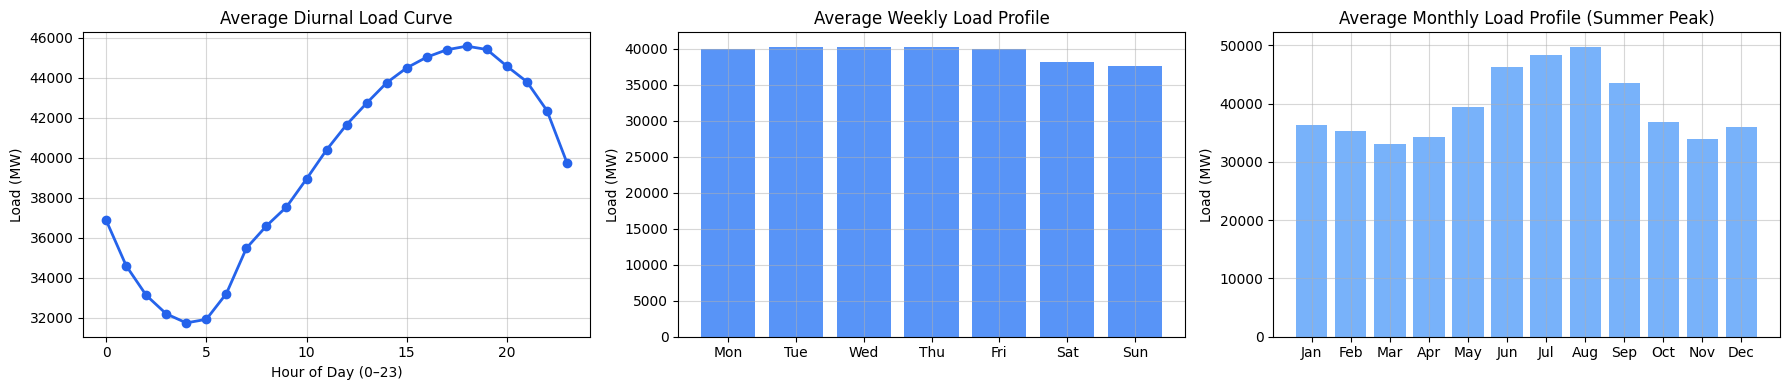

In [53]:
#Average Hourly, Daily, and Monthly Load Profiles
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hourly = ercot.groupby(ercot.index.hour)["load"].mean()
axes[0].plot(hourly.index, hourly.values, marker="o", color="#2563eb", linewidth=2)
axes[0].set_title("Average Diurnal Load Curve")
axes[0].set_xlabel("Hour of Day (0-23)")
axes[0].set_ylabel("Load (MW)")
axes[0].grid(True, alpha=0.5)

dayofweek = ercot.groupby(ercot.index.dayofweek)["load"].mean()
axes[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dayofweek.values, color="#3b82f6", alpha=0.85)
axes[1].set_title("Average Weekly Load Profile")
axes[1].set_ylabel("Load (MW)")
axes[1].grid(True, alpha=0.5)

monthly = ercot.groupby(ercot.index.month)["load"].mean()
axes[2].bar(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], monthly.values, color="#60a5fa", alpha=0.85)
axes[2].set_title("Average Monthly Load Profile (Summer Peak)")
axes[2].set_ylabel("Load (MW)")
axes[2].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [54]:
train_ercot = ercot.loc["2020-01-01 00:00:00":"2022-12-31 23:00:00"]
val_ercot   = ercot.loc["2023-01-01 00:00:00":"2023-12-31 23:00:00"]
test_ercot  = ercot.loc["2024-01-01 00:00:00":"2024-12-31 23:00:00"]

print(f"ERCOT Train (2020-2022): {len(train_ercot)} hours ({train_ercot.index.min()} to {train_ercot.index.max()})")
print(f"ERCOT Val (2023): {len(val_ercot)} hours ({val_ercot.index.min()} to {val_ercot.index.max()})")
print(f"ERCOT Test (2024): {len(test_ercot)} hours ({test_ercot.index.min()} to {test_ercot.index.max()})")

ERCOT Train (2020–2022): 26304 hours (2020-01-01 00:00:00 to 2022-12-31 23:00:00)
ERCOT Val (2023): 8760 hours (2023-01-01 00:00:00 to 2023-12-31 23:00:00)
ERCOT Test (2024): 8784 hours (2024-01-01 00:00:00 to 2024-12-31 23:00:00)


In [55]:
assert train_ercot.index.max() < val_ercot.index.min(), "Leakage between Train and Val"
assert val_ercot.index.max() < test_ercot.index.min(), "Leakage between Val and Test"
print("ERCOT split temporal integrity confirmed.")

ERCOT split temporal integrity confirmed.


In [56]:
OUT_DIR = Path("/mnt/c/Users/Vikash Rathore/OneDrive/Desktop/Energy Load Predictor/data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [57]:
ercot.to_parquet(OUT_DIR / "ercot_clean.parquet")

In [58]:
train_ercot.index.to_series().to_frame("timestamp").to_parquet(OUT_DIR / "ercot_train_idx.parquet")
val_ercot.index.to_series().to_frame("timestamp").to_parquet(OUT_DIR / "ercot_val_idx.parquet")
test_ercot.index.to_series().to_frame("timestamp").to_parquet(OUT_DIR / "ercot_test_idx.parquet")

print(f"Successfully generated ERCOT Parquet files in: {OUT_DIR}")

Successfully generated ERCOT Parquet files in: /mnt/c/Users/Vikash Rathore/OneDrive/Desktop/Energy Load Predictor/data/processed
